# Import Library

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import json

In [3]:
model_path = 'mobilenetv2_tb_final.h5'  
model = load_model(model_path)

print("✅ Model berhasil dimuat")
print(f"Input shape: {model.input_shape}")

# Load class indices (jika ada file json)
try:
    with open('class_indices.json', 'r') as f:
        class_indices = json.load(f)
    # Balik dictionary untuk mendapatkan nama kelas dari index
    idx_to_class = {v: k for k, v in class_indices.items()}
    print(f"✅ Class indices dimuat: {class_indices}")
except:
    # Jika tidak ada file json, buat manual
    print("⚠️ File class_indices.json tidak ditemukan, buat manual")
    # Sesuaikan dengan kelas Anda
    class_names = ['Normal', 'Tuberculosis']  # Urutan sesuai training
    idx_to_class = {i: name for i, name in enumerate(class_names)}
    print(f"✅ Class names: {class_names}")

✅ Model berhasil dimuat
Input shape: (None, 224, 224, 3)
⚠️ File class_indices.json tidak ditemukan, buat manual
✅ Class names: ['Normal', 'Tuberculosis']


In [4]:
def predict_image(image_path, model, idx_to_class, img_size=224):
    """
    Fungsi untuk memprediksi satu gambar
    
    Args:
        image_path: path ke gambar
        model: model yang sudah di-load
        idx_to_class: dictionary mapping index ke nama kelas
        img_size: ukuran input model (default 224)
    
    Returns:
        dict: hasil prediksi lengkap
    """
    
    # Baca gambar
    img = cv2.imread(image_path)
    if img is None:
        return {"error": f"Tidak dapat membaca gambar: {image_path}"}
    
    # Convert BGR ke RGB (karena cv2 baca sebagai BGR)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize
    img_resized = cv2.resize(img_rgb, (img_size, img_size))
    
    # Normalisasi (sesuai dengan training)
    img_normalized = img_resized / 255.0
    
    # Tambahkan batch dimension
    img_batch = np.expand_dims(img_normalized, axis=0)
    
    # Prediksi
    predictions = model.predict(img_batch, verbose=0)[0]
    
    # Hasil
    predicted_idx = np.argmax(predictions)
    predicted_class = idx_to_class[predicted_idx]
    confidence = predictions[predicted_idx]
    
    # Semua probabilitas
    probabilities = {}
    for i, prob in enumerate(predictions):
        probabilities[idx_to_class[i]] = float(prob)
    
    # Return hasil lengkap
    result = {
        'image_path': image_path,
        'predicted_class': predicted_class,
        'confidence': float(confidence),
        'probabilities': probabilities,
        'raw_predictions': predictions.tolist()
    }
    
    return result

def display_prediction(result, show_image=True):
    """
    Menampilkan hasil prediksi dengan visualisasi
    
    Args:
        result: hasil dari fungsi predict_image
        show_image: apakah menampilkan gambar
    """
    
    if 'error' in result:
        print(f"❌ Error: {result['error']}")
        return
    
    print("\n" + "="*60)
    print(f"📁 FILE: {os.path.basename(result['image_path'])}")
    print("="*60)
    
    # Hasil utama
    print(f"\n🎯 HASIL PREDIKSI:")
    print(f"   Kelas      : {result['predicted_class']}")
    print(f"   Confidence : {result['confidence']:.2%}")
    
    # Probabilitas per kelas
    print(f"\n📊 PROBABILITAS PER KELAS:")
    for class_name, prob in result['probabilities'].items():
        bar = '█' * int(prob * 50) + '░' * (50 - int(prob * 50))
        print(f"   {class_name:15}: {prob:6.2%} {bar}")
    
    # Status (rekomendasi)
    print(f"\n💡 REKOMENDASI:")
    if result['confidence'] > 0.95:
        print(f"   ✅ Sangat yakin (confidence > 95%)")
    elif result['confidence'] > 0.80:
        print(f"   ⚠️ Cukup yakin (confidence 80-95%)")
    else:
        print(f"   ❓ Kurang yakin (confidence < 80%) - perlu verifikasi manual")
    
    # Tampilkan gambar jika diminta
    if show_image:
        img = cv2.imread(result['image_path'])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.figure(figsize=(8, 6))
        plt.imshow(img_rgb)
        plt.title(f"Prediksi: {result['predicted_class']} ({result['confidence']:.2%})")
        plt.axis('off')
        plt.show()


📁 FILE: Normal-3.png

🎯 HASIL PREDIKSI:
   Kelas      : Normal
   Confidence : 100.00%

📊 PROBABILITAS PER KELAS:
   Normal         : 100.00% █████████████████████████████████████████████████░
   Tuberculosis   :  0.00% ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░

💡 REKOMENDASI:
   ✅ Sangat yakin (confidence > 95%)


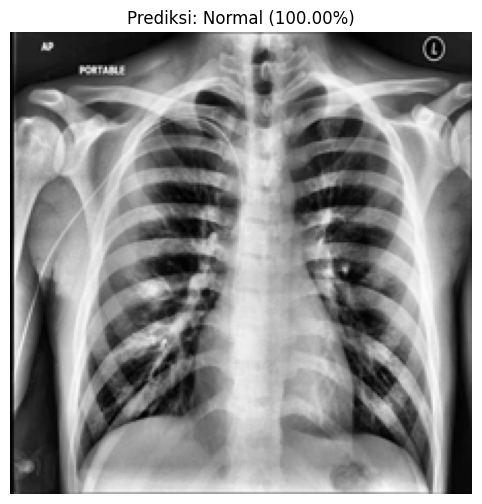

In [6]:
test_image = '../data_clean/Normal/Normal-3.png'  

# Cek apakah file ada
if os.path.exists(test_image):
    result = predict_image(test_image, model, idx_to_class)
    display_prediction(result, show_image=True)
else:
    print(f"❌ File tidak ditemukan: {test_image}")
    print("Silakan ganti 'test_image' dengan path gambar yang valid")


In [8]:
def test_multiple_images(image_paths, model, idx_to_class):
    """
    Test beberapa gambar sekaligus
    
    Args:
        image_paths: list path gambar
        model: model yang sudah di-load
        idx_to_class: mapping index ke nama kelas
    """
    
    results = []
    
    print("="*60)
    print("📊 BATCH TESTING")
    print("="*60)
    
    for i, img_path in enumerate(image_paths):
        if not os.path.exists(img_path):
            print(f"{i+1}. ❌ File tidak ditemukan: {img_path}")
            continue
        
        result = predict_image(img_path, model, idx_to_class)
        results.append(result)
        
        # Tampilkan ringkasan
        status = "✅" if result['confidence'] > 0.9 else "⚠️" if result['confidence'] > 0.7 else "❓"
        print(f"{i+1}. {status} {os.path.basename(img_path)}")
        print(f"   → {result['predicted_class']} ({result['confidence']:.2%})")
    
    return results

# Contoh penggunaan
test_images = [
    '../raw_data/Normal/Normal-1.png',
    '../raw_data/Normal/Normal-3.png',
    '../raw_data/Tuberculosis/Tuberculosis-1.png',
]  

# Filter hanya file yang ada
existing_images = [img for img in test_images if os.path.exists(img)]

if existing_images:
    results = test_multiple_images(existing_images, model, idx_to_class)
else:
    print("❌ Tidak ada file gambar yang ditemukan")

📊 BATCH TESTING
1. ✅ Normal-1.png
   → Normal (100.00%)
2. ✅ Normal-3.png
   → Normal (100.00%)
3. ✅ Tuberculosis-1.png
   → Tuberculosis (100.00%)
